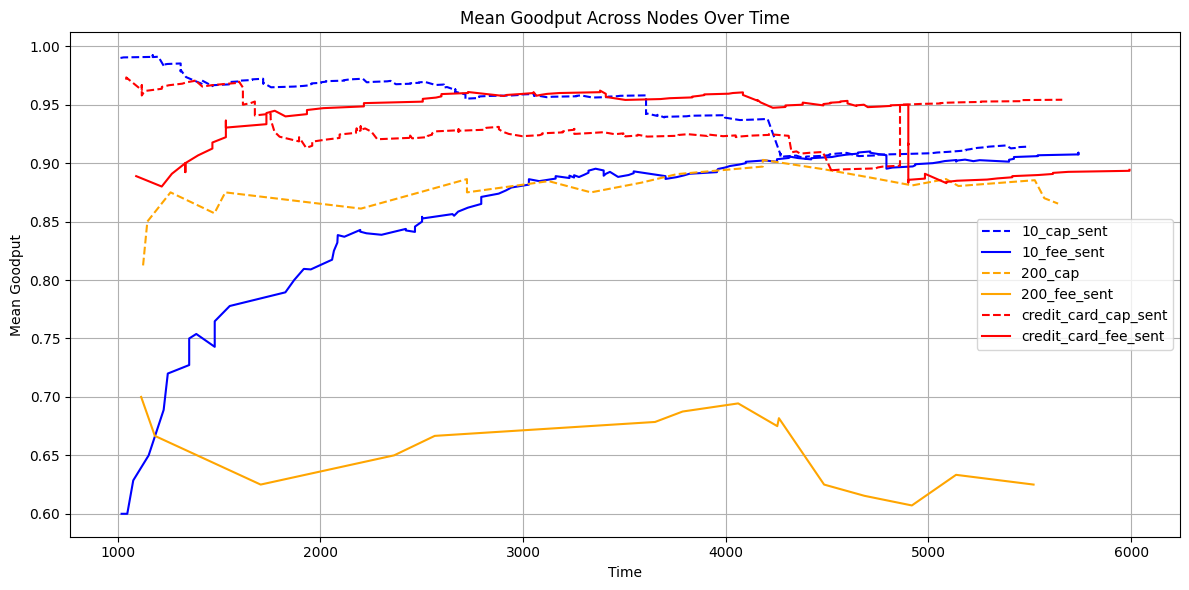

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# List your CSV files (adjust the path/pattern as needed)
csv_files = sorted(glob.glob("*.csv"))

plt.figure(figsize=(12, 6))

for csv_file in csv_files:
    # Read the header to get the number of columns
    with open(csv_file, 'r') as f:
        header = f.readline()
    
    # Generate column names
    col_names = []
    for h in header.strip().split(','):
        if h.strip() != '':
            node_name = h.split('vector')[-1].split('(')[0].strip()
            col_names.append(f"time_{node_name}")
            col_names.append(f"goodput_{node_name}")

    # Read the data, skipping the header row
    df = pd.read_csv(csv_file, skiprows=1, header=None)
    df = df.iloc[:, :len(col_names)]
    df.columns = col_names

    # Extract all goodput columns
    goodput_cols = [c for c in df.columns if c.startswith("goodput_")]
    # Compute mean goodput across all nodes for each row
    df['mean_goodput'] = df[goodput_cols].mean(axis=1)
    # Use the first time column as the x-axis
    time_col = [c for c in df.columns if c.startswith("time_")][0]

    # Filter out rows where time < 1000
    df = df[df[time_col] >= 1000]

    # Choose linestyle and color
    fname = os.path.splitext(os.path.basename(csv_file))[0]
    if 'cap' in fname:
        linestyle = '--'
    elif 'fee' in fname:
        linestyle = '-'
    else:
        linestyle = '-.'

    if '10' in fname:
        color = 'blue'
    elif '200' in fname:
        color = 'orange'
    elif 'credit_card' in fname:
        color = 'red'
    else:
        color = None  # Let matplotlib choose

    plt.plot(df[time_col], df['mean_goodput'], linestyle=linestyle, color=color, label=fname)

plt.xlabel("Time")
plt.ylabel("Mean Goodput")
plt.title("Mean Goodput Across Nodes Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()